This notebook will be used to analyze single particle tracks generated with TrackMate from organoid timecourse Batch20220930_D14.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


import sys
sys.path.append("..")

pd.set_option('display.max_columns', None)

In [3]:
#Reads in csv files "spots" from tracking

D14_pos14_ROI1_spots = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-1_raw_spots.csv')
D14_pos14_ROI1_spots.head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
0,Label,Spot ID,Track ID,Quality,X,Y,Z,T,Frame,Radius,Visibility,Custom Integer Spot Feature,Custom Double Spot Feature,Has max quality,Manual spot color,Mean intensity ch1,Median intensity ch1,Min intensity ch1,Max intensity ch1,Sum intensity ch1,Std intensity ch1,Contrast ch1,Signal/Noise ratio ch1
1,Label,Spot ID,Track ID,Quality,X,Y,Z,T,Frame,R,Visibility,Integer Spot Feature,Double Spot Feature,Max Quality,Spot color,Mean ch1,Median ch1,Min ch1,Max ch1,Sum ch1,Std ch1,Ctrst ch1,SNR ch1
2,NaN,NaN,NaN,(quality),(micron),(micron),(micron),(sec),NaN,(micron),NaN,NaN,NaN,NaN,NaN,(counts),(counts),(counts),(counts),(counts),(counts),NaN,NaN
3,ID141985,141985,0,3323.362060546875,68.45337909,112.83376238999999,0.0,0.8,16,0.20172901499999998,1,NaN,NaN,0,NaN,9387.904761904761,8758.0,7278.0,12523.0,197146.0,1566.146701454302,0.05756156438066815,0.6525189978956093
4,ID142020,142020,0,4987.6689453125,68.72235110999999,112.43030436,0.0,0.65,13,0.20172901499999998,1,NaN,NaN,1,NaN,9609.380952380952,9539.0,6085.0,14109.0,201797.0,2126.498518132342,0.0789768815874777,0.6615278982059218


In [4]:
#Removes first 3 rows of TrackMate file and resets the row indeces

D14_pos14_ROI1_spots_simple = D14_pos14_ROI1_spots.drop(labels = [0,1,2], axis = 0, inplace = False)
D14_pos14_ROI1_spots_simple = D14_pos14_ROI1_spots_simple.reset_index(drop=True)
D14_pos14_ROI1_spots_simple.head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,CONTRAST_CH1,SNR_CH1
0,ID141985,141985,0,3323.362060546875,68.45337909,112.83376238999999,0.0,0.8,16,0.20172901499999998,1,NaN,NaN,0,NaN,9387.904761904761,8758.0,7278.0,12523.0,197146.0,1566.146701454302,0.05756156438066815,0.6525189978956093
1,ID142020,142020,0,4987.6689453125,68.72235110999999,112.43030436,0.0,0.65,13,0.20172901499999998,1,NaN,NaN,1,NaN,9609.380952380952,9539.0,6085.0,14109.0,201797.0,2126.498518132342,0.0789768815874777,0.6615278982059218
2,ID141972,141972,0,6084.92724609375,68.85683712,112.56479037,0.0,0.7000000000000001,14,0.20172901499999998,1,NaN,NaN,0,NaN,8900.142857142857,8524.0,5200.0,14553.0,186903.0,2766.400337726163,0.08238973223011273,0.4897803665474724
3,ID141925,141925,0,4757.2734375,68.72235110999999,112.43030436,0.0,0.55,11,0.20172901499999998,1,NaN,NaN,0,NaN,9662.0,9328.0,5786.0,13565.0,202902.0,2103.738719518182,0.07537558606133002,0.6438367431980805
4,ID141962,141962,0,5813.06494140625,68.72235110999999,112.56479037,0.0,0.6000000000000001,12,0.20172901499999998,1,NaN,NaN,0,NaN,9841.0,9620.0,6612.0,14456.0,206661.0,2368.9025518159247,0.09101563582659235,0.6931178195447174


In [44]:
#Selects the columns TRACK_ID and MEAN_INTENSITY_CH1
#The ':' in the square brackets signifies that the rows are left untouched

track_intensities = D14_pos14_ROI1_spots_simple.iloc[:, np.r_[2,15]]

#Converts 'MEAN_INTENSITY_CH1' to type 'float', so that 'groupby' operation in next cell can be perfomed
track_intensities['MEAN_INTENSITY_CH1'] = track_intensities['MEAN_INTENSITY_CH1'].astype(float)

track_intensities.head()

#type(track_intensities)

/var/folders/x0/68qcnmdd17x84svtqbmr_7h40000gr/T/ipykernel_14099/250027170.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  track_intensities['MEAN_INTENSITY_CH1'] = track_intensities['MEAN_INTENSITY_CH1'].astype(float)


,TRACK_ID,MEAN_INTENSITY_CH1
0,0,9387.904762
1,0,9609.380952
2,0,8900.142857
3,0,9662.000000
4,0,9841.000000


In [48]:
#Calculates mean intensities based on grouping by 'TRACK_ID'

track_id = track_intensities.groupby("TRACK_ID", sort = False, as_index = False)
track_int_mean = track_id.mean().round(2) #after calculating the mean, the values are rounded to 2 decimals
track_int_mean.head()

,TRACK_ID,MEAN_INTENSITY_CH1
0,0,9252.62
1,1,8839.63
2,2,9134.94
3,3,10079.77
4,4,8162.86


(array([3., 2., 7., 3., 3., 6., 2., 5., 1., 3.]),
 array([ 5519.4  ,  5976.447,  6433.494,  6890.541,  7347.588,  7804.635,
         8261.682,  8718.729,  9175.776,  9632.823, 10089.87 ]),
 <BarContainer object of 10 artists>)

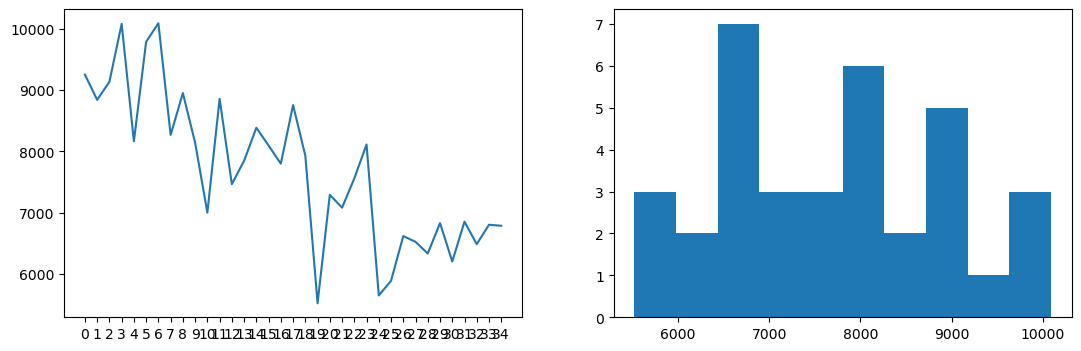

In [66]:
fig, ax = plt.subplots(1,2, figsize = (13,4))
ax[0].plot(track_int_mean["TRACK_ID"], track_int_mean["MEAN_INTENSITY_CH1"])
ax[1].hist(track_int_mean["MEAN_INTENSITY_CH1"])

In [11]:
#Reads in csv files "tracks" from tracking

D14_pos14_ROI1_tracks = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/ACTB-KI/Batch20220930/D14/Slide1/Tables/100tp-561-100-50ms-1000g_488-10-50ms-1000g_pos14_1_w1conf561-488dual_ROI-1_raw_tracks.csv')
D14_pos14_ROI1_tracks.head()

,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,Label,Track index,Track ID,Custom Integer Track Feature,Custom Double Track Feature,Number of spots in track,Number of gaps,Number of split events,Number of merge events,Number of complex points,Longest gap,Track duration,Track start,Track stop,Track displacement,Track mean X,Track mean Y,Track mean Z,Track mean speed,Track max speed,Track min speed,Track median speed,Track std speed,Track mean quality,Total distance traveled,Max distance traveled,Confinement ratio,Mean straight line speed,Linearity of forward progression,Mean directional change rate
1,Label,Index,ID,Integer Track Feature,Double Track Feature,N spots,N gaps,N splits,N merges,N complex,Lgst gap,Duration,Track start,Track stop,Track disp.,Track X,Track Y,Track Z,Mean sp.,Max speed,Min speed,Med. speed,Std speed,Mean Q,Total dist.,Max dist.,Cfn. ratio,Mn. v. line,Fwd. progr.,Mn. γ rate
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(sec),(sec),(sec),(micron),(micron),(micron),(micron),(micron/sec),(micron/sec),(micron/sec),(micron/sec),(micron/sec),(quality),(micron),(micron),NaN,(micron/sec),NaN,(rad/sec)
3,Track_198,0,0,NaN,NaN,11,1,0,0,0,1,0.55,0.25,0.8,0.7242293281039387,68.72235110999999,112.43030436,0.0,2.844780208639265,8.505642100563561,0.0,2.689720200000068,2.340345682503819,4349.876797762784,1.5568761143196361,0.7242293281039387,0.4651810901604275,1.3167805965526158,0.46287603961589263,27.210266799916717
4,Track_199,1,1,NaN,NaN,23,4,0,0,0,3,1.4000000000000001,0.25,1.6500000000000001,1.0242149380729386,69.23690627869564,109.71134807086955,0.0,3.3173265165267476,7.607677571657731,0.0,2.689720200000071,2.1792548678562134,4309.791143002717,3.9339051083707814,1.0842608761602517,0.2603557813058473,0.7315820986235275,0.22053364206954718,23.97209302276833


In [74]:
#Removes first 3 rows of TrackMate file and resets the row indeces

D14_pos14_ROI1_tracks_simple = D14_pos14_ROI1_tracks.drop(labels = [0,1,2], axis = 0, inplace = False)
D14_pos14_ROI1_tracks_simple = D14_pos14_ROI1_tracks_simple.reset_index(drop=True)
#D14_pos14_ROI1_tracks_simple.head(5)

In [67]:
#Removes tracks that are 3 frames or shorter

D14_pos14_ROI1_tracks_simple["NUMBER_SPOTS"] = pd.to_numeric(D14_pos14_ROI1_tracks_simple["NUMBER_SPOTS"])
D14_pos14_ROI1_tracks_filtered = D14_pos14_ROI1_tracks_simple[D14_pos14_ROI1_tracks_simple["NUMBER_SPOTS"] >= 4 ]
D14_pos14_ROI1_tracks_filtered = D14_pos14_ROI1_tracks_simple.reset_index(drop=True)
D14_pos14_ROI1_tracks_filtered.head()

,LABEL,TRACK_INDEX,TRACK_ID,MANUAL_INTEGER_TRACK_FEATURE,MANUAL_DOUBLE_TRACK_FEATURE,NUMBER_SPOTS,NUMBER_GAPS,NUMBER_SPLITS,NUMBER_MERGES,NUMBER_COMPLEX,LONGEST_GAP,TRACK_DURATION,TRACK_START,TRACK_STOP,TRACK_DISPLACEMENT,TRACK_X_LOCATION,TRACK_Y_LOCATION,TRACK_Z_LOCATION,TRACK_MEAN_SPEED,TRACK_MAX_SPEED,TRACK_MIN_SPEED,TRACK_MEDIAN_SPEED,TRACK_STD_SPEED,TRACK_MEAN_QUALITY,TOTAL_DISTANCE_TRAVELED,MAX_DISTANCE_TRAVELED,CONFINEMENT_RATIO,MEAN_STRAIGHT_LINE_SPEED,LINEARITY_OF_FORWARD_PROGRESSION,MEAN_DIRECTIONAL_CHANGE_RATE
0,Track_198,0,0,NaN,NaN,11,1,0,0,0,1,0.55,0.25,0.8,0.7242293281039387,68.72235110999999,112.43030436,0.0,2.844780208639265,8.505642100563561,0.0,2.689720200000068,2.340345682503819,4349.876797762784,1.5568761143196361,0.7242293281039387,0.4651810901604275,1.3167805965526158,0.46287603961589263,27.210266799916717
1,Track_199,1,1,NaN,NaN,23,4,0,0,0,3,1.4000000000000001,0.25,1.6500000000000001,1.0242149380729386,69.23690627869564,109.71134807086955,0.0,3.3173265165267476,7.607677571657731,0.0,2.689720200000071,2.1792548678562134,4309.791143002717,3.9339051083707814,1.0842608761602517,0.2603557813058473,0.7315820986235275,0.22053364206954718,23.97209302276833
2,Track_200,2,2,NaN,NaN,6,0,0,0,0,0,0.25,0.25,0.5,0.26897201999999254,64.82225681999999,119.73737756999999,0.0,3.227664240000024,5.379440400000136,0.0,2.689720200000068,2.250381373901228,4277.764811197917,0.806916060000006,0.26897201999999254,0.3333333333333216,1.0758880799999702,0.3333333333333216,31.41592653589794
3,Track_201,3,3,NaN,NaN,11,0,0,0,0,0,0.5,0.25,0.75,0.300719860382705,66.91290297545454,113.4817404381818,0.0,3.513983637931103,8.06916059999992,0.0,3.8038387858287646,2.5250755496005914,6017.379438920455,1.756991818965552,0.4034580299999959,0.17115609596848155,0.60143972076541,0.1711560959684816,30.70092530390546
4,Track_202,4,4,NaN,NaN,3,0,0,0,0,0,0.10000000000000003,0.25,0.35000000000000003,0.300719860382724,64.73259947999999,118.07871678,0.0,3.2467794929145173,3.8038387858289697,2.6897202000000653,3.8038387858289697,0.787800807085585,3550.8347981770835,0.32467794929145183,0.300719860382724,0.9262096826685896,3.007198603827239,0.9262096826685895,15.70796326794897
